# Data Understanding and Validation

---

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('/content/drive/MyDrive/Business intelligence and prediction/online_retail.csv')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [5]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [6]:
df['InvoiceDate'].describe()

,InvoiceDate
count,541909
unique,23260
top,2011-10-31 14:41:00
freq,1114


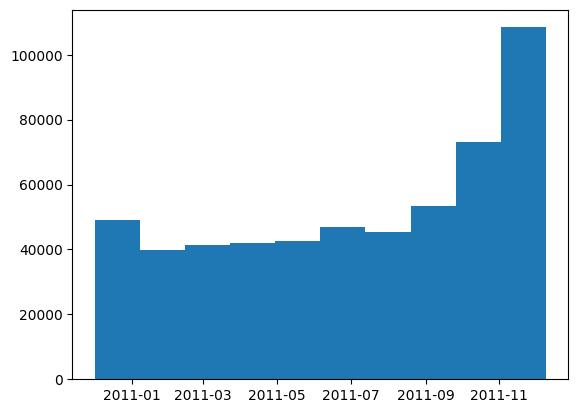

In [7]:
import matplotlib.pyplot as plt
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

plt.hist(df['InvoiceDate'])
plt.show()

In [8]:
up = df['UnitPrice']<0
q = df['Quantity']<0
swc = df['InvoiceNo'].apply(lambda x: x.startswith('C'))
print(swc.value_counts())
print(up.value_counts())
print(q.value_counts())
print(df['CustomerID'].describe())

InvoiceNo
False    532621
True       9288
Name: count, dtype: int64
UnitPrice
False    541907
True          2
Name: count, dtype: int64
Quantity
False    531285
True      10624
Name: count, dtype: int64
count    406829.000000
mean      15287.690570
std        1713.600303
min       12346.000000
25%       13953.000000
50%       15152.000000
75%       16791.000000
max       18287.000000
Name: CustomerID, dtype: float64


# Data Cleaning
---

In [9]:
# Removing rows with InvoiceNo starting with "C" -- Canceled order
df.drop(df[df['InvoiceNo'].apply(lambda x: x.startswith("C"))].index, inplace = True)
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


In [10]:
# Remove the tuples with negative quantities, neg unitprice and null customer IDs
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]
df = df[df['CustomerID'].notnull()]

In [11]:
# Validate InovoiceDate dtype and also change the dtype of customerID int
print(df['InvoiceDate'].dtype)
df['CustomerID'] = pd.to_numeric(df['CustomerID'], downcast='integer').astype('int64')
print(df['CustomerID'].dtype)

datetime64[ns]
int64


In [12]:
# Create a feature - Revenue = Quantity * UnitPrice
df["Revenue"] = df['Quantity']*df['UnitPrice']

In [13]:
# Check for negative values in unitprice and quantity and also the remaining row count
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,Revenue
count,397884.000000,397884,397884.000000,397884.000000,397884.000000
mean,12.988238,2011-07-10 23:41:23.511023360,3.116488,15294.423453,22.397000
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000,0.001000
25%,2.000000,2011-04-07 11:12:00,1.250000,13969.000000,4.680000
50%,6.000000,2011-07-31 14:39:00,1.950000,15159.000000,11.800000
75%,12.000000,2011-10-20 14:33:00,3.750000,16795.000000,19.800000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000,168469.600000
std,179.331775,NaN,22.097877,1713.141560,309.071041


In [14]:
# Check if there are still null customer IDs in the df
df['CustomerID'].isnull().sum()

np.int64(0)

# BI Analysis
---

In [15]:
# Check for total transactions and unique customers, unique products and total contries the business is operated
print("DF shape = ", df.shape)
df.nunique().get(['StockCode','CustomerID','Country'])

DF shape =  (397884, 9)


,0
StockCode,3665
CustomerID,4338
Country,37


count    397884.000000
mean         22.397000
std         309.071041
min           0.001000
25%           4.680000
50%          11.800000
75%          19.800000
max      168469.600000
Name: Revenue, dtype: float64
348325      7144.72
173382      8142.75
222680     38970.00
61619      77183.60
540421    168469.60
Name: Revenue, dtype: float64


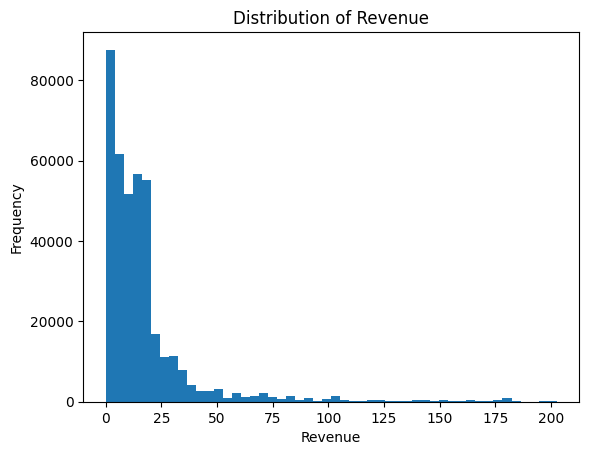

In [16]:
# Check and analyse revenue data to understand revenue distribution
print(df['Revenue'].describe())

# Check for outliers
print(df['Revenue'].sort_values().tail())

# Calculate the 99th percentile for Revenue to set an appropriate x-axis limit since there are outliers
revenue_99th_percentile = df['Revenue'].quantile(0.99)
plt.hist(df['Revenue'], bins=50, range=(0, revenue_99th_percentile))
plt.title('Distribution of Revenue')
plt.xlabel('Revenue')
plt.ylabel('Frequency')
plt.show()

count      4338.000000
mean       2054.266460
std        8989.230441
min           3.750000
25%         307.415000
50%         674.485000
75%        1661.740000
max      280206.020000
Name: Revenue, dtype: float64


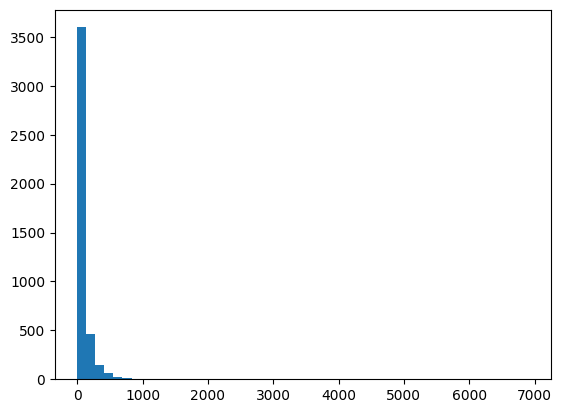

In [17]:
# Check revenue per customer and also get the top 20 revenue generating customers
revenue_per_customer = df.groupby('CustomerID')['Revenue'].sum()
print(revenue_per_customer.describe())

# High revenue customers
high_revenue_customers = df.groupby('CustomerID').count()['Revenue']
# top_20_customers = high_revenue_customers.sort_values(ascending=False).head(20)
# print(top_20_customers)
plt.hist(high_revenue_customers, bins=50, range=(0, high_revenue_customers.quantile(0.9999)))
plt.show()

In [18]:
# Purchase Frequency
purchase_frequency = df.groupby('CustomerID')['InvoiceNo'].nunique()
print(purchase_frequency.describe())

count    4338.000000
mean        4.272015
std         7.697998
min         1.000000
25%         1.000000
50%         2.000000
75%         5.000000
max       209.000000
Name: InvoiceNo, dtype: float64


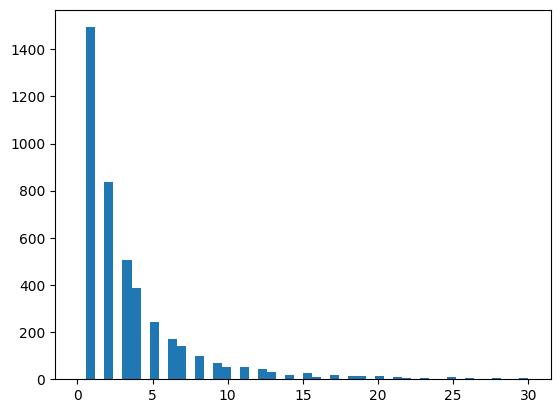

In [19]:
plt.hist(purchase_frequency, bins = 50, range= (0,purchase_frequency.quantile(0.99)))
plt.show()

In [27]:
# Calculate the recency of purchase, how much recent is the last purchase of customers taking the last date from the DF as reference
reference_date = df['InvoiceDate'].max()
recent_purchase = df.groupby('CustomerID')['InvoiceDate'].max()
recency = (reference_date - recent_purchase)
recency = recency.dt.days
recency.describe()

,InvoiceDate
count,4338.000000
mean,91.536422
std,100.014169
min,0.000000
25%,17.000000
50%,50.000000
75%,141.000000
max,373.000000


# RFM table creation and Customer Segmentataion
---

In [39]:
# RFM and customer segments using RFM scores
# Now from the calculated Frequency, Monetary and Recency make a RFM table
rfm = pd.DataFrame({'Recency': recency, 'Frequency' : purchase_frequency, 'Monetary' : revenue_per_customer})

# Calculate RFM scores and overall score
rfm['R_score'] = (pd.qcut(rfm['Recency'], 3, labels=[3, 2, 1])).astype(int)
rfm['F_score'] = (pd.qcut(rfm['Frequency'].rank(method = 'first'), 3, labels=[1, 2, 3])).astype(int)
rfm['M_score'] = (pd.qcut(rfm['Monetary'], 3, labels=[1, 2, 3])).astype(int)
rfm['RFM_score'] = rfm['F_score'] + rfm['M_score'] + rfm['R_score']

# Create customer segments using RFM score
def segment_customer(score):
  if score >= 7:
    return "High Value"
  elif score >= 4:
    return "Medium Value"
  else:
    return "Low Value"

rfm['Customer_Segment'] = rfm['RFM_score'].apply(segment_customer)

# Check Distribution
rfm['Customer_Segment'].value_counts()

,count
Customer_Segment,
Medium Value,1901
High Value,1810
Low Value,627
